# 03 - End-to-end walkthrough

This notebook is the user-facing tutorial.  It explains, step by step, what `run_certification` does internally and what each knob in `ProbeConfig` controls.  It is meant to be skimmable in 5 minutes.

### What the certificate is
Given a closed loop *(LLM agent, environment, prompt)* the certificate returns a single number `phase_margin` and a regime label.  Positive margin -> the loop is predicted to converge.  Margin near zero -> oscillatory (limit cycle).  Margin negative in any probing direction -> exploratory (diverges).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))
import numpy as np
from phase_margin.loops import SyntheticLTILoop
from phase_margin.probe import random_vector_basis
from phase_margin.types import ProbeConfig
from phase_margin import run_certification, classify_regime

loop = SyntheticLTILoop.from_random(d=4, spectral_radius=0.5, seed=7)
basis = random_vector_basis(dim=4, n_directions=3, seed=7)
report = run_certification(loop=loop, basis=basis,
                          config=ProbeConfig(horizon=32, n_seeds=4,
                                            n_seeds_nominal=2,
                                            n_frequencies=6,
                                            epsilon=0.05),
                          use_text_perturbation=False, progress=False)
print(report.summary())

phase margin Φ = +2.634 rad (+150.9°)
predicted regime: contractive
per-direction margins:
  v0                        Φ_v = +2.634
  v1                        Φ_v = +2.917
  v2                        Φ_v = +3.008
notes: loop=SyntheticLTILoop, dim=4


### Inspecting the spectra
`report.agent_spectra[name]` is a `DirectionalSpectrum` with one `PhaseFit` per probed frequency.  We can plot the empirical phase response.

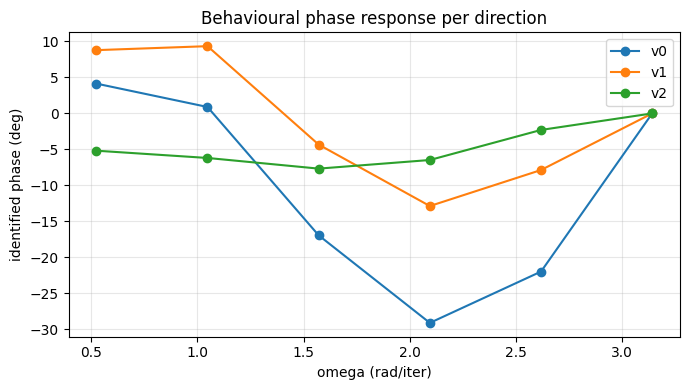

In [2]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 4))
for name, spec in report.agent_spectra.items():
    ax.plot(spec.omegas, np.degrees(spec.thetas), 'o-', label=name)
ax.set_xlabel('omega (rad/iter)')
ax.set_ylabel('identified phase (deg)')
ax.set_title('Behavioural phase response per direction')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.savefig('../results/03_walkthrough_spectra.png', dpi=120); plt.show()

### What the knobs do
| `ProbeConfig` field | meaning |
|---|---|
| `horizon` (`N`) | rollout length per probe trial |
| `n_seeds` (`M`) | seeds averaged per (direction, frequency) |
| `n_seeds_nominal` (`M_0`) | seeds for the nominal-trajectory mean |
| `n_frequencies` (`|G|`) | grid size of probe frequencies in (0, pi] |
| `epsilon` | probe amplitude (smaller = more linear, noisier) |
| `residual_cap` | drop a frequency from the sector if fit residual exceeds this |
| `margin_buffer` | width of the oscillatory band around margin = 0 |

### Where the regime classifier lives

In [3]:
from phase_margin.margin import compute_phase_margin
margin, per_dir = compute_phase_margin(report.agent_spectra)
print('phase margin:', margin, '   per dir:', per_dir)
regime = classify_regime(margin, per_dir, margin_buffer=0.05)
print('regime:', regime.value)

phase margin: 2.633667201994835    per dir: {'v0': 2.633667201994835, 'v1': 2.91700036027722, 'v2': 3.0077185605246233}
regime: contractive


### Production usage pattern
1. Wrap your real agent in an `AgentLoop` subclass that exposes `step(...)` and an `Embedder`.
2. Choose a probing basis (`text_basis_paraphrase` is a sensible default for natural-language loops).
3. Call `run_certification(loop, basis, config, use_text_perturbation=True)` once per deployment configuration.
4. Reject deployments where `report.regime` is `OSCILLATORY` or `EXPLORATORY`.